In [1]:
from langchain_ollama import ChatOllama

model = ChatOllama(model="gpt-oss:120b-cloud")
print('Model is ready')

c:\Users\ak60492\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Model is ready


In [2]:
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, AnyMessage
from langgraph.graph.message import add_messages

class ReActState(TypedDict):
    messages: Annotated[
        list[AnyMessage],
        add_messages
    ]

print('ReAct State is ready')

ReAct State is ready


In [3]:
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode

# Addition node
@tool
def add(x: int, y: int):
    """Adds two numbers"""
    return x + y

# Multiplication node
@tool
def multiply(x: int, y: int):
    """Multiplies two numbers"""
    return x * y

TOOLS = [add, multiply]
tool_node = ToolNode(TOOLS)

llm_with_tools = model.bind_tools(TOOLS)
def generate_answer(state:ReActState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages": [response] }

def should_continue(state: ReActState):
    last_message = state["messages"][-1]

    if last_message.tool_calls:
        return "tools"

    return "end"

print('Nodes are ready')

Nodes are ready


Graph is ready


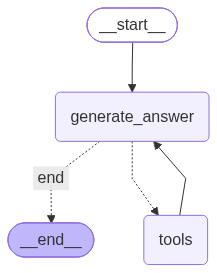

In [4]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(ReActState)

builder.add_node("generate_answer", generate_answer)
builder.add_node("tools", tool_node)

builder.add_edge(START, "generate_answer")
builder.add_conditional_edges(
    "generate_answer",
    should_continue,
    {
        "tools": "tools",
        "end": END
    }
)
builder.add_edge("tools", "generate_answer")

graph = builder.compile()
print('Graph is ready')
graph

In [ ]:
result = graph.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "What is 10 + 20, and then multiply the result by 5?"
            }
        ]
    }
)

result

{'messages': [HumanMessage(content='What is 10 + 20, and then multiply the result by 5?', additional_kwargs={}, response_metadata={}, id='ab775d33-6d76-4451-bcb7-9e77c26dee8e'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'gpt-oss:120b', 'created_at': '2026-09-24T04:47:13.499489995Z', 'done': True, 'done_reason': 'stop', 'total_duration': 356577489, 'load_duration': None, 'prompt_eval_count': 165, 'prompt_eval_duration': None, 'eval_count': 63, 'eval_duration': None, 'logprobs': None, 'model_name': 'gpt-oss:120b', 'model_provider': 'ollama'}, id='lc_run--01a0d1bd-2b1c-7e52-b147-1e03488c270f-0', tool_calls=[{'name': 'add', 'args': {'x': 10, 'y': 20}, 'id': '8d5edfc7-7c2d-41f7-9820-c902ec5872e4', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 165, 'output_tokens': 63, 'total_tokens': 228}),
  ToolMessage(content='30', name='add', id='7e6bc3b5-225a-470b-99cc-c33b692e2f76', tool_call_id='8d5edfc7-7c2d-41f7-9820-c902ec5872e4'),
  

In [ ]:
response = graph.invoke({
    "question": "What is the result of 2 plus 3, finally multiplied by 5"
})

response